In [47]:
import torch
from torch import nn, optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
from datetime import datetime
import numpy as np
from torch.utils.data import Dataset
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F


# Getting the same results with train and train_manual_update
- Write torch.manual_seed(42) at the beginning of your notebook.
- Write torch.set_default_dtype(torch.double) at the beginning of your notebook to alleviate precision errors

In [48]:
torch.manual_seed(42)
torch.set_default_dtype(torch.double)

In [49]:
device = (torch.device('cuda') if torch.cuda.is_available()
          else torch.device('cpu'))
print(f"Training on device {device}.")

Training on device cpu.


# Tasks
Load, analyse and preprocess the CIFAR-10 dataset. Split it into 3
datasets: training, validation and test. Take a subset of these datasets
by keeping only 2 labels: cat and car

In [50]:
def show_img(img, label) -> None:
    img = img.squeeze().permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

Files already downloaded and verified


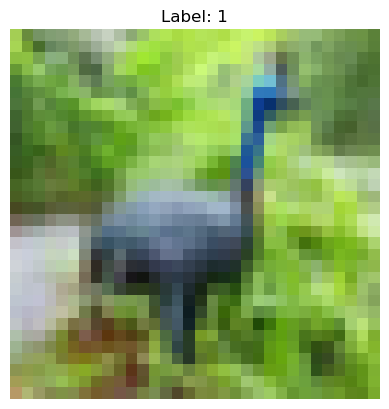

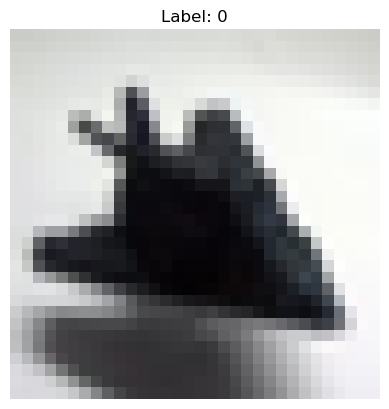

In [51]:
class CIFAR2(Dataset):
    def __init__(self, data_path: Path):
        self.data_path = data_path
        self.data, self.targets = self.__loaddata__()

        self.transformer = transforms.Compose([
            transforms.ToTensor(),
            # TODO: is this the correct normalization for CIFAR10?
            # transforms.Normalize((0.4915, 0.4823, 0.4468),
            #                      (0.2470, 0.2435, 0.2616))
        ])
    
    def __loaddata__(self):
        data = datasets.CIFAR10(
            root=str(self.data_path),
            transform=None,
            download=True
        )
        targets = np.array(data.targets)
        indices = (targets == 0) | (targets == 2) # plane, bird

        images, targets = data.data[indices], targets[indices]

        # resample 0 is ok, 2 -> 1
        targets = [1 if t == 2 else t for t in targets]

        return images, targets

    def __getitem__(self, idx) -> tuple[torch.Tensor, int]:
        img, target = self.data[idx], self.targets[idx]        
        return self.transformer(img), target

    def __len__(self):
        return len(self.data)

cifar = CIFAR2("data/")
img, label = cifar[0]
show_img(img, label) # bird = 1
img, label = cifar[4]
show_img(img, label) # plane = 0

In [52]:
def load_cifar(train_val_split=0.9, data_path='data/', preprocessor=None):
    cifar2 = CIFAR2(Path(data_path))

    train_size = int(len(cifar2) * train_val_split)
    val_test_size = len(cifar2) - train_size

    cifar_generator = torch.Generator().manual_seed(42)
    train, val_test = random_split(cifar2, lengths=[train_size, val_test_size], generator=cifar_generator)
    
    test_val_split = 0.5 # 0.05, 0.05
    val_size = int(len(val_test) * test_val_split)
    test_size = len(val_test) - val_size
    
    val, test = random_split(val_test, lengths=[val_size, test_size], generator=cifar_generator)    

    batch_size = 32
    train_loader = DataLoader(train, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

def compute_accuracy(model, loader):
    # todo
    train_loader,val_loader,test_loader = load_cifar()

    return 

Write a MyMLP class that implements a MLP in PyTorch (so only fully
connected layers) such that:
    
    - The input dimension is 768(= 16 ∗ 16 ∗ 3) and the output dimension is 2 (for the 2 classes).
    - The hidden layers have respectively 128 and 32 hidden units.
    - All activation functions are ReLU. The last layer has no activation function since the cross-entropy loss already includes a softmax activation
function.

In [53]:
class MyNet(nn.Module):
    """
    inp layer: 3072 - 512 relu
    hid layer: 512 - 128 relu
    hid layer: 128 - 32 relu
    out layer: 32 - 2 no activation function
    """
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32*32*3, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 32)
        self.fc4 = nn.Linear(32, 2)

    def forward(self, x):
        out = torch.flatten(x, 1)
        out = F.relu(self.fc1(out))
        out = F.relu(self.fc2(out))
        out = self.fc3(out)
        # no softmax, we are using cross entropy loss
        return out

Write a train(n_epochs, optimizer, model, loss_fn, train_loader) function that trains model for n_epochs epochs given an optimizer optimizer, a loss function loss_fn and a dataloader train_loader.

In [54]:
def train(n_epochs, optimizer, model, loss_fn, train_loader):
    
    n_batch = len(train_loader)
    losses_train = []
    model.train() # set to train mode
    optimizer.zero_grad(set_to_none=True)
    
    for epoch in range(1, n_epochs + 1):
        loss_train = 0.0
        for imgs, labels in train_loader:

            imgs = imgs.to(device=device) 
            labels = labels.to(device=device)

            outputs = model(imgs)
            
            loss = loss_fn(outputs, labels)
            loss.backward()
            
            optimizer.step()
            optimizer.zero_grad()

            loss_train += loss.item()
            
        losses_train.append(loss_train / n_batch)

        if epoch == 1 or epoch % 10 == 0:
            print('{}  |  Epoch {}  |  Training loss {:.3f}'.format(
                datetime.now().time(), epoch, loss_train / n_batch))
    return losses_train

In [55]:
net = MyNet()
cifar = CIFAR2("data/")

Files already downloaded and verified


Write a similar function train manual_update that has no optimizer parameter, but a learning rate lr parameter instead and that manually updates each trainable parameter of model using equation (2). Do not forget to zero out all gradients after each iteration. 

Train 2 instances of MyMLP, one using train and the other using train_manual_update (use the same parameter values for both models). Compare their respective training losses. To get exactly the same results with both functions, see section 3.3

In [56]:
def train_manual_update(n_epochs, model, loss_fn, train_loader, lr, weight_decay, momentum):
    n_batch = len(train_loader)
    model.train()
    losses_train = []

    velocities = [torch.zeros_like(p.data) for p in model.parameters()]

    for epoch in range(1, n_epochs + 1):
        loss_train = 0.0
        for imgs, labels in train_loader:
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            loss.backward()

            with torch.no_grad():
                for v, p in zip(velocities, model.parameters()):
                    if p.grad is not None:
                        grad = p.grad + weight_decay * p.data
                        v.mul_(momentum).add_(grad)
                        p.data -= lr * v

            model.zero_grad(set_to_none=True)

            loss_train += loss.item()

        if epoch == 1 or epoch % 10 == 0:
            print('{}  |  Epoch {}  |  Training loss {:.3f}'.format(
                datetime.now().time(), epoch, loss_train / n_batch))

        losses_train.append(loss_train / len(train_loader))
    return losses_train

Files already downloaded and verified
22:02:17.706841  |  Epoch 1  |  Training loss 0.776
22:02:26.949519  |  Epoch 10  |  Training loss 0.469
22:02:37.304648  |  Epoch 20  |  Training loss 0.391
22:02:47.604689  |  Epoch 30  |  Training loss 0.340
22:02:49.458802  |  Epoch 1  |  Training loss 0.790
22:03:06.794576  |  Epoch 10  |  Training loss 0.467
22:03:26.951973  |  Epoch 20  |  Training loss 0.391
22:03:46.145211  |  Epoch 30  |  Training loss 0.342


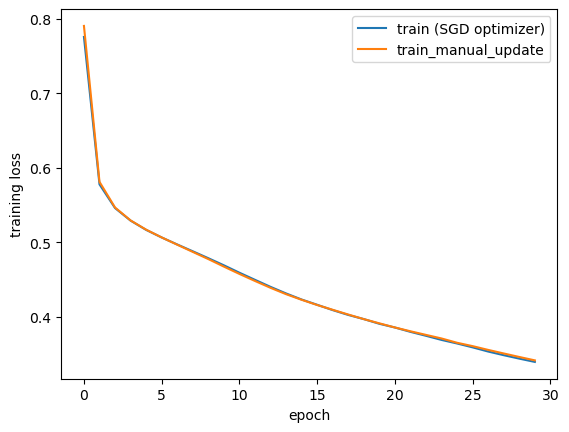

In [57]:
# 3.1.5

n_epochs = 30
lr = 1e-2

loss_fn = nn.CrossEntropyLoss()

train_loader, val_loader, test_loader = load_cifar()

# instance 1: train
model_opt = MyNet().to(device)
optimizer = torch.optim.SGD(model_opt.parameters(), lr=lr, momentum=0.0, weight_decay=0.0)
losses_opt = train(n_epochs, optimizer, model_opt, loss_fn, train_loader)

# instance 2: train_manual_update
model_man = MyNet().to(device)
losses_man = train_manual_update(n_epochs, model_man, loss_fn, train_loader, lr=lr, weight_decay=0.0, momentum=0.0)


plt.plot(losses_opt, label="train (SGD optimizer)")
plt.plot(losses_man, label="train_manual_update")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("training loss")
plt.show()

Files already downloaded and verified
22:03:48.190954  |  Epoch 1  |  Training loss 0.781
22:03:59.677675  |  Epoch 10  |  Training loss 0.473
22:04:11.806689  |  Epoch 20  |  Training loss 0.400
22:04:24.893004  |  Epoch 30  |  Training loss 0.352
22:04:27.011728  |  Epoch 1  |  Training loss 0.789
22:04:47.590318  |  Epoch 10  |  Training loss 0.468
22:05:09.126226  |  Epoch 20  |  Training loss 0.395
22:05:30.480396  |  Epoch 30  |  Training loss 0.347


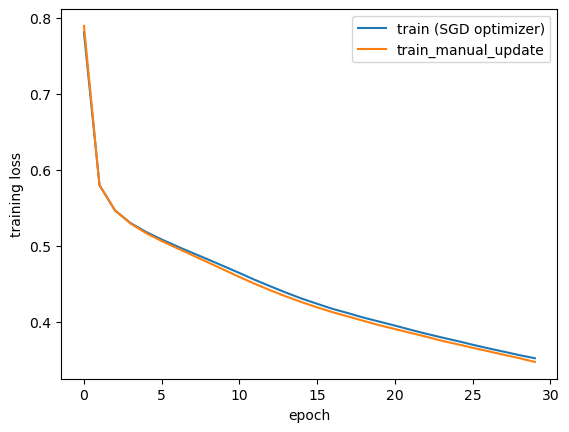

In [58]:
# 3.1.6

n_epochs = 30
lr = 1e-2

wd = 1e-3

loss_fn = nn.CrossEntropyLoss()

train_loader, val_loader, test_loader = load_cifar()

# instance 1: train
model_opt = MyNet().to(device)
optimizer = torch.optim.SGD(model_opt.parameters(), lr=lr, momentum=0.0, weight_decay=wd)
losses_opt = train(n_epochs, optimizer, model_opt, loss_fn, train_loader)

# instance 2: train_manual_update
model_man = MyNet().to(device)
losses_man = losses_man = train_manual_update(n_epochs, model_man, loss_fn, train_loader, lr=lr, weight_decay=wd, momentum=0.0)


plt.plot(losses_opt, label="train (SGD optimizer)")
plt.plot(losses_man, label="train_manual_update")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("training loss")
plt.show()

Files already downloaded and verified
22:05:32.977234  |  Epoch 1  |  Training loss 0.724
22:05:46.935059  |  Epoch 10  |  Training loss 0.428
22:06:02.135912  |  Epoch 20  |  Training loss 0.387
22:06:17.718482  |  Epoch 30  |  Training loss 0.355
22:06:19.623558  |  Epoch 1  |  Training loss 0.763
22:06:37.256585  |  Epoch 10  |  Training loss 0.428
22:06:55.951680  |  Epoch 20  |  Training loss 0.382
22:07:14.623737  |  Epoch 30  |  Training loss 0.363


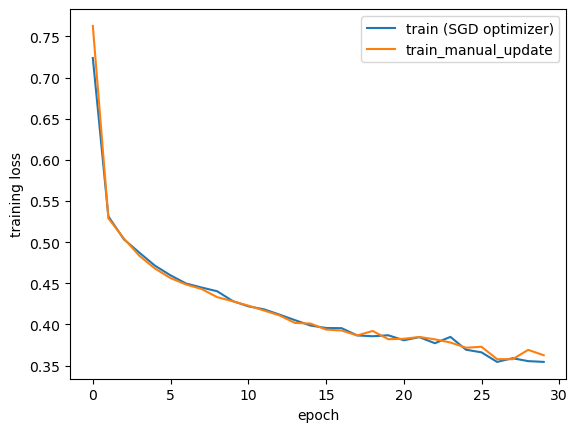

In [59]:
# 3.1.7

n_epochs = 30
lr = 1e-2

wd = 1e-3

momentum = 0.9

loss_fn = nn.CrossEntropyLoss()

train_loader, val_loader, test_loader = load_cifar()

# instance 1: train
model_opt = MyNet().to(device)
optimizer = torch.optim.SGD(model_opt.parameters(), lr=lr, momentum=momentum, weight_decay=wd)
losses_opt = train(n_epochs, optimizer, model_opt, loss_fn, train_loader)

# instance 2: train_manual_update
model_man = MyNet().to(device)
losses_man = losses_man = train_manual_update(n_epochs, model_man, loss_fn, train_loader, lr=lr, weight_decay=wd, momentum=momentum)


plt.plot(losses_opt, label="train (SGD optimizer)")
plt.plot(losses_man, label="train_manual_update")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("training loss")
plt.show()